# Korrektur

- Viel Erfolg!

### Bewertung

#### _/20 Punkte

----

In [32]:
'''import standard libraries'''
import numpy as np                       # mathematical methods
from matplotlib import pyplot as plt     # plotting methods within notebook
from scipy import stats                  # lots of statistical methods
from scipy.stats import gaussian_kde
import pandas as pd                      # read and treat datasets
%matplotlib inline

# Übungsaufgaben 11: Anova
---

# Bitte lösen sie die Aufgaben 
- innerhalb dieses Notebooks 
- welches Sie bitte umbenennen in `A11_IHRNAME.ipynb` (IHRNAME passend ersetzen)

und laden das ausgeführte Notebook dann rechtzeitig wieder in ilias hoch.

#### Danke!

### Hinweise

wie gehabt.

---

# Aufgabe 1) Theorie der Anova
Eine One-Way Anova testet die Nullhypothese, dass die Mittelwerte aller zu testenden Gruppen gleich sind:
$$\mu_1 = \mu_2 = \dots = \mu_{total}$$

Sie heißt jedoch Analysis of Variance. 

### a) Beschreiben Sie 
in eigenen Worten, was die Anova testet und warum das sinnvoll ist.

Die Nullhypothese der ANOVA ist, dass die Mittelwerte von mindestens zwei unabhängigen Gruppen gleich sind. Somit können sie signifikante Abweichungen bzw. Varianz nachweisen. Es wird die Streuung zwischen den Gruppen und innerhalb der Gruppe verglichen. Ist die Varianz zwischen den Gruppen größer als innerhalb, deutet dies auf einen Unterschied. Umgekehrt sind die Gruppen vereinbar.
Das Ziel ist mehrere Gruppen und deren Ähnlichkeit gleichzeitig zu vergleichen statt einzelne Tests zwischen den Gruppen.

### b) Eine alternative Sichtweise 
auf die Anova bietet der Satz der totalen Varianz
$$\mathrm{Var}(Y) = \mathrm{Var}\bigl(\mathcal{E}(Y|X)\bigr) + \mathcal{E}\bigl(\mathrm{Var}(Y|X)\bigr) $$
Interpretieren Sie, was der Satz bedeutet, insbesondere für eine Anova.

$ Var\mathrm{Y} \rightarrow $ Gesamtvarianz

$ \mathrm{Var}\bigl(\mathcal{E}(Y|X)\bigr) \rightarrow $ Varianz des Erwartungswerte

$ \mathcal{E}\bigl(\mathrm{Var}(Y|X)\bigr) \rightarrow $ Erwartungswert der Varianzen

Der Satz besagt, dass die gesamte Variation der Daten die Summe aus der Variation der Erwartungswerte (Unterschiede zwischen den Gruppen) und die erwartete Variation innerhalb der Gruppen ist. Und diese zwei Summanden sind auch interessant für die ANOVA, welche die Variation innerhalb einer Gruppe (Rauschen von Stichprobendaten) mit der Variation über die Gesamtdatenmenge ins Verhältnis setzt.

### [Bonus] c) Beweis (nur für fortgeschritten mathematisch Interessierte!)
Beweisen Sie den Satz der totalen Varianz. Obacht: aufwändig! (3 Punkte für eigene Lösung; 1 Punkt für *saubere* Fundstelle in Lehrbuch/Journal oder im Internet; kein Punkt für Abschreiben oder KI, da keinerlei Lerneffekt, weder für mich noch für Sie, sparen Sie sich also die unnütze Zeit des bloßen Abschreibens) 

Hilfestellungen:
- Varianz als Erwartungswert
- Verschiebungssatz
- Erwartungswerte abhängig?
- Erwartungswert vom Erwartungswert
- Erwartungswert vom Erwartungswert einer bedingten Verteilung marginalisiert

### d) Quadratfehlersummen
Formulieren Sie den Satz der totalen Varianz in Quadratfehlersummen SQ*X* durch Schätzung um. 
(Es sollte so etwas ähnliches wie in den Folien herauskommen)

Satz der totalen Varianz in Quadratsummen:

$$ SQT = SQE + SQR $$

$$ \sum_{i=1}^{k} \sum_{j=1}^{n_i} (Y_{ij}-\overline{Y_j})^2 = \sum_{i=1}^{k} n_i \cdot (\overline{Y_i}-\overline{Y_{total}})^2 + \sum_{i=1}^{k} \sum_{j=1}^{n_i} (Y_{ij}-\overline{Y_i})^2$$

Summe der quadrierten Abweichungen aller Einzelwerte vom Gesamtmittelwert: $\sum_{i=1}^{k} \sum_{j=1}^{n_i} (Y_{ij}-\overline{Y_j})^2$

Summe der quadrierten Abweichungen der Gruppenmittelwerte vom Gesamtmittelwert. Gewichtet mit der Gruppengröße: $\sum_{i=1}^{k} n_i \cdot (\overline{Y_i}-\overline{Y_{total}})^2$

Summe der quadrierten Abweichungen der Einzelwerte von ihrem jeweiligen Gruppenmittelwert: $\sum_{i=1}^{k} n_i \cdot (\overline{Y_i}-\overline{Y_{total}})^2$

### e) Varianzen, Quadratsummen und Freiheitsgrade
Die Verbindung der Aspekte die Sie in a) b) und d) angesehen haben, erlaubt die Angabe der "erklärten Varianz". Leiten Sie diese *erklärte Varianz* $R^2$ her.

DIe erklärte Varianz $R^2$ gibt an, welcher Anteil der totalen Streuung durch die Gruppeneinteilung erklärt werden kann.

aus d):
$$ SQT = SQE + SQR $$

Teilen durch SQT:
$$ 1 = \frac{SQE}{SQT} + \frac{SQR}{SQT} $$

$\frac{SQE}{SQT}$ gibt den Anteil der Variation wider, welcher durch die Unterschiede der Gruppen verursacht wird. Also, welcher auf die Gruppeneinteilung zurückgeht.

Somit können wir annehmen:

$$ R^2 = \frac{SQE}{SQT} = \frac{SQE}{SQE + SQR} $$


### f) Vergleich und Interpretation
Ihnen liegen die Daten von gemessenen Versuchsergebnissen vor.

Das Ergebnis ist:
> Die One-way Anova hat einen F-Wert ergeben, der im Verwerfungsbereich für $F(\mathrm{df}_c=\dots, \mathrm{df}_t=\dots)$ liegt. Daher wird die Nullhypothese verworfen, wir schlussfolgern daher einen Effekt.

Vergleichen/beschreiben Sie dann die drei alternativen möglichen Beschreibungen/Interpretationen, die Sie aus den Varianzen, den Fehlerquadratsummen oder der erklärten Varianz für Ihre gemessenen Daten bekommen. Eine allgemeine Beschreibung wie im Beispiel "F" ist ausreichend.

1. Varianzen: Die Varianz zwischen den Gruppen ist signifikant größer als die Varianz innerhalb der Gruppen.
2. Fehlerquadratsummen: Die Summe der quadrierten Abweichungen, die durch die Gruppenmittelwerte erklärt wird, ist im Verhältnis zur verbleibenden Fehlerquadratsumme groß. Die Gruppenmittelwerte reduzieren den Gesamtfehler besser als nur der globale Mittelwert.
3. Erklärte Varianz: Ein signifikanter Anteil der totalen Streuung wird durch die Gruppenzugehörigkeit erklärt. Ein hohes $R^2$ wird erwartet.

$\color{green}{6+3 \text{ Punkte}}$

## Korrektur

 Punkte

---

# Aufgabe 2) Gut Kirschen essen?

Erinnern Sie sich an die statistische Auswertung der Kirschenernte aus früheren Aufgabenblättern.

Sie haben inzwischen an 6 Wochenenden Marmelade gekocht und die Anzahl der Würmer in den jeweils 180 Kirschen bestimmt: 
- [9, 15, 13, 13, 10, 11].

Ihr Nachbar hat ebenfalls Kirschbäume:
- Für 5 Bäume im Gewächshaus hat er jeweils 300 Kirschen auf Würmer untersucht: [7, 7, 8, 8, 10]
- Für 10 behandelte Bäume im Freien hat er jeweils 333 Kirschen auf Würmer untersucht: [12, 10, 6, 10, 7, 13, 12, 7, 9, 10]

## Unterscheiden sich die Kirschbaumanbaumethoden?
... im Hinblick auf Wurmbefall ...

### a) Beschreiben Sie zunächst ihr Vorgehen. Null- und Alternativhypothese?

Vorgehen: Da die Stichprobenumfänge variieren, müssen die Gruppen zuerst normalisiert werden. Dies würde eine Art Wurmbefallrate ergeben. Anschließend wird ein One-Way ANOVA durchgeführt.

Nullhypothese: $\mu_{selbst} = \mu_{gewächshaus} = \mu_{behandelt} \rightarrow$ kein signifikanter Unterschied im Wurmbefall zwischen den Methoden
Alternativhypothese: Mindestens einer der Mittelwerte unterscheidet sich von den anderen.

In [17]:
# data
worms_self = np.array([9, 15, 13, 13, 10, 11])
worms_greenhouse = np.array([7, 7, 8, 8, 10])
worms_treated = np.array([12, 10, 6, 10, 7, 13, 12, 7, 9, 10])
n_self = 180
n_greenhouse = 300
n_treated = 333

# norm data
factor = 1000
norm_self = (worms_self / n_self) * factor
norm_greenhouse = (worms_greenhouse / n_greenhouse) * factor
norm_treated = (worms_treated / n_treated) * factor

# worms per 1000 cherries
print(f"Selbst:        {norm_self}")
print(f"Gewächshaus:    {norm_greenhouse}")
print(f"Behandelt:     {norm_treated}")

Selbst:        [50.         83.33333333 72.22222222 72.22222222 55.55555556 61.11111111]
Gewächshaus:    [23.33333333 23.33333333 26.66666667 26.66666667 33.33333333]
Behandelt:     [36.03603604 30.03003003 18.01801802 30.03003003 21.02102102 39.03903904
 36.03603604 21.02102102 27.02702703 30.03003003]


### b) Überprüfen Sie die Voraussetzungen für eine Anova.
per Theorie (Begründung) und Graphik (Augenschein genügt, kein expliziter Test notwendig)

- normalverteilte Streuung / Rauschen
- stetiges Merkmal $Y$
- Klassierte unabhängige Variable $X$

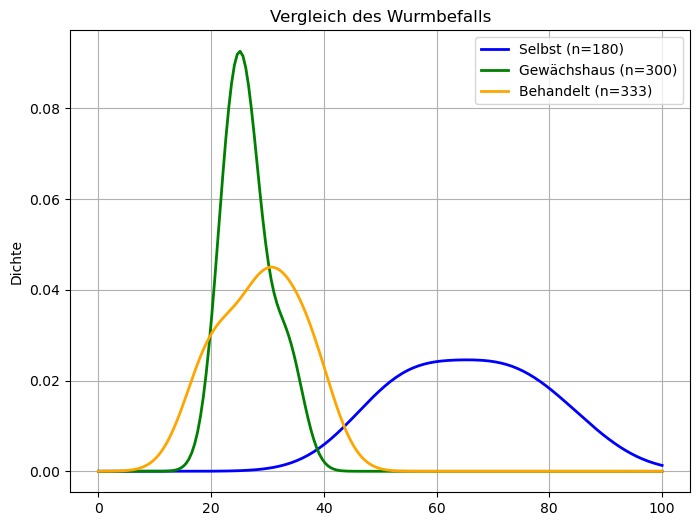

Varianz Selbst:        153.29
Varianz Gewächshaus:    16.67
Varianz Behandelt:     50.50


In [19]:
# data
data_2b = [norm_self, norm_greenhouse, norm_treated]
labels_2b = ["Selbst (n=180)", "Gewächshaus (n=300)", "Behandelt (n=333)"]
colours_2b = ["blue", "green", "orange"]

# plot
plt.figure(figsize = (8,6))
x_grid = np.linspace(0, 100, 200)
for data, labels, colours in zip(data_2b, labels_2b, colours_2b):
    kde = gaussian_kde(data)
    plt.plot(x_grid, kde(x_grid), color = colours, linewidth = 2, label = labels)
plt.title("Vergleich des Wurmbefalls")
plt.ylabel("Dichte")
plt.legend()
plt.grid()
plt.show()

# variance
print(f"Varianz Selbst:        {np.var(norm_self, ddof = 1):.2f}")
print(f"Varianz Gewächshaus:    {np.var(norm_greenhouse, ddof = 1):.2f}")
print(f"Varianz Behandelt:     {np.var(norm_treated, ddof = 1):.2f}")

- normalverteilte Streuung / Rauschen
    $\rightarrow$ trifft zu, die Glockenform trifft annähernd zu
- stetiges Merkmal $Y$
    $\rightarrow$ trifft zu, der normierte Wurmbefall ist diskret (kann jeden positiven Wert annehmen)
- Klassierte unabhängige Variable $X$
    $\rightarrow$ trifft zu, Anbaumethode, Person und Herkunft sind unterschiedlich

### c) Was sagt Ihr Bauchgefühl aus der Graphik aus b) zur Fragestellung "Unterschied"?

Ich nehme an, das es einen Unterschied geben wird (H0 wird abgelehnt). Zwar liegen die "Gewächshaus" und "behandelt" Daten sehr nahe aneinander, aber die "selbst" Daten liegen deutlich weiter rechts. Ebenso ist die Varianz deutlich größer.

### d) Berechnen Sie zur Anova den F-Wert
- mittels `numpy` gemäß der passenden Formel aus SQE und SQR
- und vergleichen Sie diesen mit dem berechneten Verwerfungsbereich
    - gehen Sie dabei von einem $\alpha$-Fehlerniveau von 4% aus
- (2 P.)

In [44]:
# means
mean_greenhouse = np.mean(norm_greenhouse)
mean_treated = np.mean(norm_treated)
mean_self = np.mean(norm_self)

# amount of measurements
m_self = len(worms_self)
m_greenhouse = len(worms_greenhouse)
m_treated = len(worms_treated)

# add total data
k = 3
n_total = n_self + n_greenhouse + n_treated
m_total = m_self + m_greenhouse + m_treated
norm_total = np.concatenate((norm_self, norm_greenhouse, norm_treated))
mean_total = np.mean(norm_total)

# SQE
sqe = m_self * ((mean_self - mean_total) ** 2) + m_greenhouse * ((mean_greenhouse - mean_total) ** 2) + m_treated * ((mean_treated - mean_total) ** 2)

# SQR
sqr = (np.sum((norm_self - mean_self) ** 2) + np.sum((norm_greenhouse - mean_greenhouse) ** 2) + np.sum((norm_treated - mean_treated) ** 2))

#DoF
df_between = k - 1
df_within = m_total - k

# mean squares
ms_between = sqe / df_between
ms_within = sqr / df_within

# F-value
f_value = ms_between / ms_within

alpha = 0.04
f_crit = stats.f.ppf(1 - alpha, df_between, df_within)
p_value = 1 - stats.f.cdf(f_value, df_between, df_within)

print(f"SQE: {sqe:.2f} (df = {df_between})")
print(f"SQE: {sqr:.2f} (df = {df_within})")
print(f"Berechneter F-Wert: {f_value:.2f}")
print(f"Kritischer F-Wert: {f_crit:.4f}")
print(f"p-Wert: {p_value:.20f}")


SQE: 6085.08 (df = 2)
SQE: 1287.64 (df = 18)
Berechneter F-Wert: 42.53
Kritischer F-Wert: 3.8697
p-Wert: 0.00000015117946805532


### e) Verwenden Sie nun `scipy.stats.f_oneway`
Was ist Ihr Ergebnis?

In [43]:
f_stat, p_stat = stats.f_oneway(norm_self, norm_greenhouse, norm_treated)

print(f"Berechneter F-Wert: {f_stat:.2f}")
print(f"p-Wert: {p_stat:.20f}")

Berechneter F-Wert: 42.53
p-Wert: 0.00000015117946800080


### f) Welche Baumanbaumethode ist besser?
Im Hinblick auf minimale Wurmanzahl; den Marmeladengeschmack können wir leider nicht testen.
Dieses Vorgehen, nach der (erfolgreichen) Anova, nennt sich *post-hoc-Test*
(2P.)

In [48]:
print(f"Mittelwert Selbst: {mean_self:.0f} Würmer pro Kirsche")
print(f"Mittelwert Gewächshaus: {mean_greenhouse:.0f} Würmer pro Kirsche")
print(f"Mittelwert Behandelt: {mean_treated:.0f} Würmer pro Kirsche")

Mittelwert Selbst: 66 Würmer pro Kirsche
Mittelwert Gewächshaus: 27 Würmer pro Kirsche
Mittelwert Behandelt: 29 Würmer pro Kirsche


Die beste Methode ist das Gewächshaus des Nachbar. Mit der Methode werden im Schnitt nur 27 Würmer pro 1000 Kirschen sein. Danach folgt die Methode mit den behandelten Bäumen im Freien mit 29 Würmer. Deutlich schlechter sieht es bei den eigenen Kirschen aus, aber vielleicht reisen sie es ja mit dem besseren Geschmack heraus.

$\color{green}{8 \text{ Punkte}}$

## Korrektur

 Punkte

---

# Aufgabe 3) Aussagen über das Schulsystem
Werten Sie erneut den Datensatz der Schüler zweier portugiesischen Schulen aus (siehe A10_Aufgaben, dort auch Hinweise zum Einlesen des Datensatzes).

### a) Überprüfen Sie, ob die Note `'G3'` der Schüler von der aufgebrachten Lernzeit `'studytime'` abhängt. 
- Welcher Test ist angebracht?
- Nullhypothese?
- Statistik?
- Ergebniswert der Statistik
- Entscheidung?

- One-Way ANOVA: kategoriale unabhängige Variable mit 4 Gruppen (studytime) und metrische abhänige Variable (G3)
- Nullhypothese: die durschnittlichen Abschlussnoten sind für alle Lernzeitgruppen gleich - Die lernzeit hat keinen einfluss auf die note

In [54]:
# import data
pupils = pd.read_csv('student-mat.csv', sep=';')

# collect wanted data
groups = [pupils[pupils["studytime"] == i]["G3"] for i in sorted(pupils["studytime"].unique())]

# means
print("Mittelwerte pro Gruppe")
print(pupils.groupby("studytime")["G3"].mean())

# One-Way ANOVA
f_val_3a, p_val_3a = stats.f_oneway(*groups)

# results
print(f"\nF-Wert: {f_val_3a:4f}")
print(f"p-Wert: {p_val_3a:4f}")

Mittelwerte pro Gruppe
studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64

F-Wert: 1.727835
p-Wert: 0.160723


Mit 0.16 ist der p-Wert deutlich höher als ein übliches Signifikanzniveau. deshalb wird die Nullhypothese nicht verworfen. Statistisch lässt sich mit den Date nnicht sagen, dass die Lernzeit einen signifikanten Einfluss auf die Schulnoten hat.

### b) Erstellen Sie eine aussagekräftige Graphik der Verteilung 
der Noten für die Kategorien "aufgebrachte Studienzeit" (siehe a)). 

####  Interpretieren sie diese Graphik, war der Test in a) angebracht?


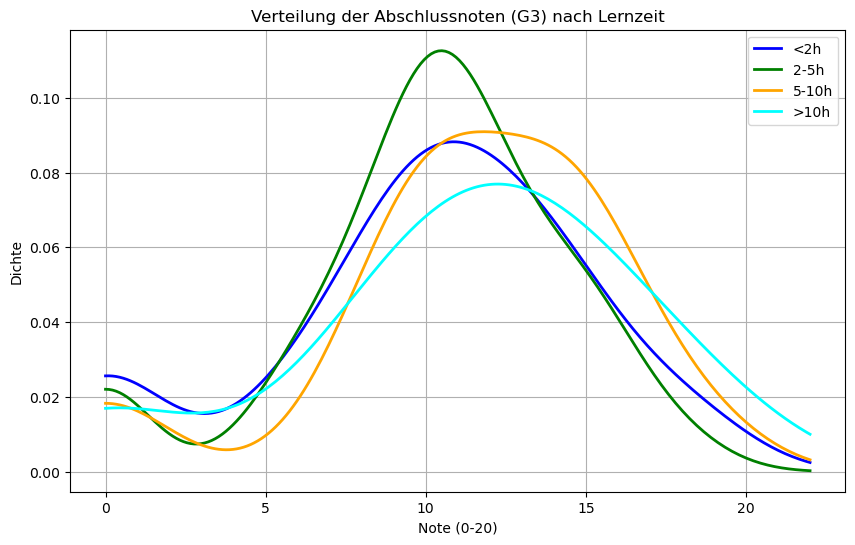

In [60]:
# data
data_3b = groups
labels_3b = ["<2h", "2-5h", "5-10h", ">10h"]
colours_3b = ["blue", "green", "orange", "cyan"]

# plot
plt.figure(figsize = (10,6))

x_grid = np.linspace(0, 22, 200)

for data, labels, colours in zip(data_3b, labels_3b, colours_3b):
    kde = gaussian_kde(data)
    plt.plot(x_grid, kde(x_grid), color = colours, linewidth = 2, label = labels)

plt.title("Verteilung der Abschlussnoten (G3) nach Lernzeit")
plt.ylabel("Dichte")
plt.xlabel("Note (0-20)")
plt.legend()
plt.grid()
plt.show()


Die Kurven zeigen eine deutliche Überlagerung. Ebenso sind die Mittelwerte (Gipfel) sehr nahe aneinander. Das keine klare Trennung zu erkennen ist, bestätigt die Resultate in a).

Der Test war angebracht, da die Voraussetzungen (siehe 2b) gegeben sind.

### c) Abschlußalter und Alkohol?
Erstellen Sie eine Graphik der Verteilung des Abschlußalters `'age'` für Gruppen mit unterschiedlichem Alkoholkonsum `Walc` in Litern/Woche analog zu a) und b) und führen einen passenden Test durch.

#### Ergebnis, Interpretation?


F-Wert: 3.031631
p-Wert: 0.017558


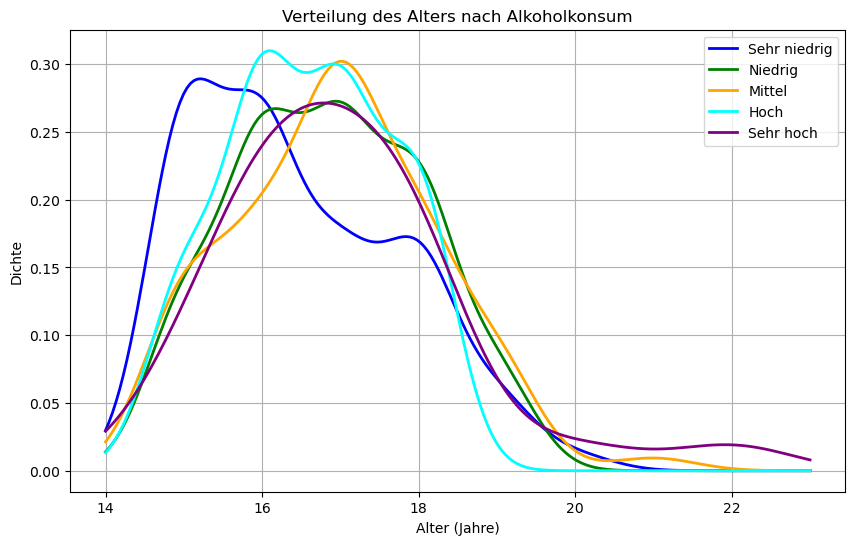

In [61]:
# data
data_3c = [pupils[pupils["Walc"] == i]["age"] for i in sorted(pupils["Walc"].unique())]
labels_3c = ["Sehr niedrig", "Niedrig", "Mittel", "Hoch", "Sehr hoch"]
colours_3c = ["blue", "green", "orange", "cyan", "purple"]

# One-Way ANOVA
f_val_3c, p_val_3c = stats.f_oneway(*data_3c)

# results
print(f"\nF-Wert: {f_val_3c:4f}")
print(f"p-Wert: {p_val_3c:4f}")

# plot
plt.figure(figsize = (10,6))

x_grid = np.linspace(14, 23, 200)

for data, labels, colours in zip(data_3c, labels_3c, colours_3c):
    kde = gaussian_kde(data)
    plt.plot(x_grid, kde(x_grid), color = colours, linewidth = 2, label = labels)

plt.title("Verteilung des Alters nach Alkoholkonsum")
plt.ylabel("Dichte")
plt.xlabel("Alter (Jahre)")
plt.legend()
plt.grid()
plt.show()

Der p-Wert liegt unter dem üblichen Signifikanzniveau $\rightarrow$ kein sign. Unterschied im Alter zwischen den verschiedenen Alkoholkonsum-Gruppen.


### d) Zur Überprüfung der Residuan
erstellen Sie eine Graphik der Residuenverteilung und testen, ob diese Verteilung zur Voraussetzung einer Anova paßt. Auch hier genügt bereits eine Graphik.

#### Interpretation?

keine Zeit mehr :(

$\color{green}{6 \text{ Punkte}}$

## Korrektur

 Punkte

---

### Hinweis: Nur noch ein Aufgabenblatt A12 zu linearen Modellen

---